<a href="https://colab.research.google.com/github/aaminah06/nlp/blob/main/CITS4012_Lab01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 01

# PyTorch

[PyTorch](https://pytorch.org/) is an open source machine learning library used for applications such as natural language processing and computer vision. It is based on the [Torch](http://torch.ch/) library.

Before we use Pytorch it is (obviously) neccessary to understand what Pytorch is. Let's start from the two core concepts: **Tensor**, **(Computational) Graph** and **Automatic Differentiation**


## Tensor
A tensor is a generalization of vectors and matrices to potentially higher dimensions. It is the primary data structure used by neural networks. Normally, we can use **nd**-tensor to call any of its instances where **nd** stands for **n** **dimensional**.

There are three basic attributes we need to know about tensors:
*   *Rank*: The number of dimensions present within the tensor. e.g. rank-2 tensor means 2d-tensor.
*   *Axes*: Used to refer to a specific dimensions. The number of axes equals to the number of dimensions. The length of an axis represents the number of elements running along this axis.
*   *Shape*: Formed by the length of each axis. e.g. shape(1,2) means a 2d-tensor with the first axis of length 1 and the second axis of length 2.


![Tensor_Rank](https://drive.google.com/uc?id=1o5wulLHGxUuPxH3t3xfV8U7d2CrsL1oG)


A [torch.Tensor](https://pytorch.org/docs/stable/tensors.html) (tensor in PyTorch) has the following key properties :
*   *torch.dtype*: an object representing the data type of a torch.Tensor. e.g. torch.float32
*   *torch.device*: an object representing the device on which a torch.Tensor is or will be allocated. e.g. CPU or CUDA (GPU)
*   *torch.layout*: an object representing the memory layout of a torch.Tensor.

More details with illustrative examples can be found [here](https://pytorch.org/docs/stable/tensor_attributes.html#tensor-attributes-doc)




In [2]:
import torch

## Computational Graph and Automatic Differentiation
PyTorch uses (directed acyclic) computational graphs  to graph the functional operations that are applied to tensors inside neural networks so as to computationally calculate derivatives for the network optimization. In graphs, the nodes are Tensors while the edges are functions that produce output Tensors from input Tensors (e.g. summation, mutiplication). Those graphs enable PyTorch to do the automatic differentiation for us, i.e. it can automatically calculate the derivatives that are needed for network optimization. We will learn more about it through pratical examples in following sections.

Specifically, PyTorch generates the computational graph on the fly as when operations are created during forward passes in neural networks, which is refered as dynamic computational graph.  



## Importing PyTorch library
[Google Colab](https://colab.research.google.com/notebooks/welcome.ipynb) has torch library installed as default so you just need to import it as below:

In [3]:
print(torch.__version__) #check version

2.11.0+cu128


## Tensor creation
With PyTorch, we will be implementing lots of models. To get started, let's  have a look at how to create a tensor.

We can creating tensors **with numerical data**, typically numpy arrays.

In [13]:
import numpy as np
print(torch.tensor(1).shape)    # scalar (0 Rank)
print(torch.tensor(np.array([1,2])).shape) # Vector (1 rank)
print(torch.tensor(np.ones((2,2,))).shape) # Matrix (2 rank)
print(torch.tensor(np.ones((2,2,2))).shape) # Cube (3 rank)
print(torch.tensor(np.ones((2,2,2,2))).shape) # Vector of cubes (4 rank)

torch.Size([])
torch.Size([2])
torch.Size([2, 2])
torch.Size([2, 2, 2])
torch.Size([2, 2, 2, 2])


In [15]:
data = np.array([1,2])
print(data.dtype) # int64

data_T = torch.tensor(data)
print(data_T) # tensor [1,2]
print(data_T.dtype) # torch.int64
print(data_T.dtype==torch.get_default_dtype()) #get the torch default data type,

#which can also be changed through 'torch.set_default_dtype(dtype)'. False because default is float32
print()

data_t = torch.tensor(data)
print(data_t)
print(data_t.dtype)
print()

#we can also specify a datatype with torch.tensor()
data_t = torch.tensor(data, dtype=torch.float64)
print(data_t)
print(data_t.dtype)

int64
tensor([1, 2])
torch.int64
False

tensor([1, 2])
torch.int64

tensor([1., 2.], dtype=torch.float64)
torch.float64


As well as torch.tensor(), we can also use torch.as_tensor and torch.from_numpy

In [16]:
# Create tensor using torch.as_tensor
data = np.ones((2,2,2))
data = torch.as_tensor(data) # - like torch.tensor() but tried to avoid copying the data is possible (shares memoery with the original numpy when it can). Slightly faster and more efficient
print(data.shape)

# Create tensor using torch.from_numpy - shared memory witht the numpy array (no copy at all). Changing one chages the other!
data = np.ones((2,2,2,2))
data = torch.from_numpy(data)
print(data.shape)

torch.Size([2, 2, 2])
torch.Size([2, 2, 2, 2])


In [17]:
np.ones((2,2,2))

array([[[1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.]]])

Alternatively, we can also create tensors **without data** using factory functions

In [18]:
# torch.eye: Returns an identity matrix (2x2)
torch.eye(2)

tensor([[1., 0.],
        [0., 1.]])

In [19]:
# torch.zeros: Returns a tensor of given shape filled with all zeros
torch.zeros(2,2)

tensor([[0., 0.],
        [0., 0.]])

In [20]:
# torch.ones: Returns a tensor of given shape filled with all ones
torch.ones(2,2)

tensor([[1., 1.],
        [1., 1.]])

In [21]:
# torch.rand: Returns a tensor of given shape filled with values drawn from a uniform distribution on [0, 1).
torch.rand(2,2)

tensor([[0.8381, 0.8753],
        [0.2947, 0.4004]])

More factory functions for tensor creation can be found [here](https://pytorch.org/cppdocs/notes/tensor_creation.html#factory-functions)

## Basic tensor operations

The list of operations with examples can be found [here](https://pytorch.org/docs/stable/torch.html#math-operations). Please go through and try to practise yourself with examples before you move on. You don't need to remember all of them, you can easily refer back when needed.

## Simple Linear Regression

The following code implements a simple linear regression algorithm.



### Linear Regression from scratch

Prepare data

In [22]:
import numpy
import matplotlib.pyplot as plt
import torch

# training data
x_training = numpy.asarray([1,2,5,8,9,12,14,16,18,20])
y_training = numpy.asarray([1500,3500,7200,11000,12500,18500,22000,24500,28000,30500])

x_test = numpy.asarray([3,7,13,15,19])
y_test = numpy.asarray([4400,10000,19500,23500,29000])

# creating tensors for training from training data
x_data = torch.from_numpy(x_training)
y_data = torch.from_numpy(y_training)
x_test_data = torch.from_numpy(x_test)
y_test_data = torch.from_numpy(y_test)


 Once the dataset is prepared, we can start defining our model architecture

 Let's first build it from scratch so as to gain a clear understanding about how the automatic differentiation works



In [23]:
# Define weights and biases
weight = torch.tensor(numpy.random.randn(), requires_grad=True)
bias = torch.tensor(numpy.random.randn(), requires_grad=True)
print(weight)
print(bias)

tensor(-0.1874, requires_grad=True)
tensor(0.4442, requires_grad=True)


Note that we set 'requires_grad=True' above, which turns on the automatic gradient computation for weight and bias.

Every Tensor has a flag: 'requires_grad' that allows for fine grained exclusion of subgraphs from gradient computation and can increase efficiency. If there’s a single input to an operation that requires gradient, its output will also require gradient. Conversely, the output won’t require gradient only if all inputs don’t require gradient. Backward computation is not performed in the subgraphs where all Tensors don’t require gradients.

**Why not turn it on for everything? Tracking costs extra memory and computation. You only need gradients for things you intend to update during training (the weight and bias) — not for your raw input data or test data.**

In [24]:
# Define the model
# Hypothesis = W * X + b (Linear Model)
def linearRegression(x):
  return x * weight + bias

In [25]:
# Generate predictions and compare with ground truth labels
# As we can see, we randomly initialise the weight and bias, the model does not predict properly at the moment
predictions = linearRegression(x_data)
print(predictions)
print(y_data)

tensor([ 0.2568,  0.0695, -0.4926, -1.0547, -1.2421, -1.8042, -2.1789, -2.5536,
        -2.9283, -3.3031], grad_fn=<AddBackward0>)
tensor([ 1500,  3500,  7200, 11000, 12500, 18500, 22000, 24500, 28000, 30500])


In [26]:
# Define loss function
# here we use mean squared error (MSE)
def mse(x1, x2):
  diff = x1 - x2
  return torch.sum(diff*diff)/diff.numel()

In [27]:
# Compute loss
# As we all know, the lower, the better
loss = mse(predictions, y_data)
print(loss)

tensor(3.4851e+08, grad_fn=<DivBackward0>)


As is mentioned, PyTorch automatically computes the gradient/derivative of the loss (with regard to the weight and bias here). This was enabled when we set 'requires_grad=True'.

All we need to do now is to call the backward() function over our loss, which will trigger the automatic computation of gradients based on the chain rule.

In [28]:
# Compute gradients
loss.backward()

After the backward pass, the gradients are stored in the .grad property of the involved tensors. Let's have a look.

In [29]:
# Gradient for weight
print(weight)
print(weight.grad)
print()

# Gradient for bias
print(bias)
print(bias.grad)

tensor(-0.1874, requires_grad=True)
tensor(-456246.6875)

tensor(0.4442, requires_grad=True)
tensor(-31843.0469)


Now we can easily adjust the weight and bias using the gradients.

We need to reset the gradients before the next forward pass, because PyTorch accumulates gradients.

In [30]:
# We do not want gradient for the update operation
# There will not be automatic gradient computation within the torch.no_grad()
# We use learning rate of 1e-5 here

with torch.no_grad():
  weight -= weight.grad * 1e-5
  bias -= bias.grad * 1e-5
  # remember to reset the gradients
  weight.grad.zero_()
  bias.grad.zero_()
print(weight)
print(bias)


tensor(4.3751, requires_grad=True)
tensor(0.7626, requires_grad=True)


In [31]:
print(weight.grad)
print(bias.grad)

tensor(0.)
tensor(0.)


Let's predict and compute loss again. The loss should be lower with new weights and biases

In [32]:
predictions = linearRegression(x_data)
loss = mse(predictions, y_data)
print(loss)

tensor(3.4642e+08, grad_fn=<DivBackward0>)


Hope you now have an initial clear understanding of how automatic gradient computing works.

Let's start training the model for multiple epochs.

We can just simply create a python loop to do it.

**Epoch** — Definition: one complete pass through the entire training dataset. Training almost never works after a single update — you repeat the predict → measure loss → compute gradient → update cycle many times (here, 5000 times), and the weight/bias gradually improve each time (hence "gradient descent" — the loss descends, like walking downhill).

Epoch: 0000 loss= 344340640.00000000 W= 8.9239 b= 1.0801
Epoch: 0200 loss= 103632256.00000000 W= 691.4481 b= 48.5865
Epoch: 0400 loss= 31401408.00000000 W= 1065.3453 b= 74.3793
Epoch: 0600 loss= 9726545.00000000 W= 1270.1797 b= 88.2779
Epoch: 0800 loss= 3222317.25000000 W= 1382.4032 b= 95.6612
Epoch: 1000 loss= 1270503.62500000 W= 1443.8936 b= 99.4756
Epoch: 1200 loss= 684714.37500000 W= 1477.5939 b= 101.3353
Epoch: 1400 loss= 508847.43750000 W= 1496.0702 b= 102.1245
Epoch: 1600 loss= 455981.56250000 W= 1506.2074 b= 102.3276
Epoch: 1800 loss= 440025.84375000 W= 1511.7773 b= 102.2098
Epoch: 2000 loss= 435147.43750000 W= 1514.8444 b= 101.9164
Epoch: 2200 loss= 433593.65625000 W= 1516.5406 b= 101.5271
Epoch: 2400 loss= 433037.50000000 W= 1517.4861 b= 101.0855
Epoch: 2600 loss= 432780.75000000 W= 1518.0199 b= 100.6155
Epoch: 2800 loss= 432614.00000000 W= 1518.3284 b= 100.1302
Epoch: 3000 loss= 432475.31250000 W= 1518.5127 b= 99.6366
Epoch: 3200 loss= 432344.43750000 W= 1518.6295 b= 99.1389

/tmp/ipykernel_1153/1369277692.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(x_training, weight.data * x_training + bias.data, label='Linear')


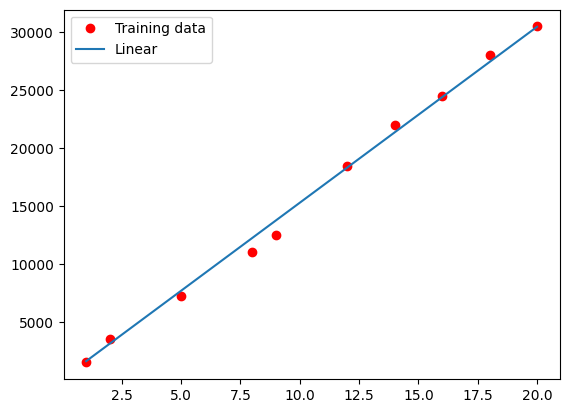

/tmp/ipykernel_1153/1369277692.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(x_test, weight.data * x_test + bias.data, label='Linear')


Testing loss= 219266.593750000
Absolute mean square loss difference: 211942.906250000


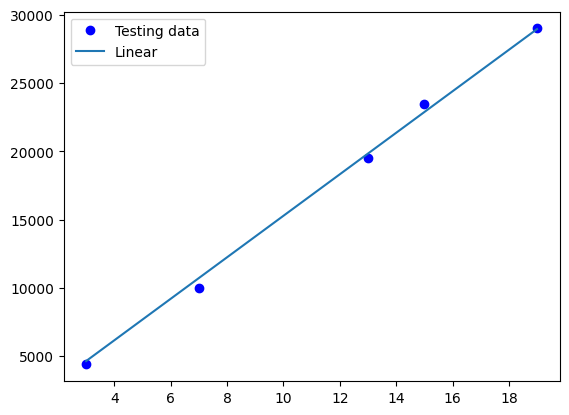

In [33]:
# An epoch is one iteration over the entire input data
no_of_epochs = 5000
# How often you want to display training info.
display_interval = 200

for epoch in range(no_of_epochs):
  predictions = linearRegression(x_data)
  loss = mse(predictions, y_data)
  loss.backward()
  with torch.no_grad():
    weight -= weight.grad * 1e-5   # update weight and bias
    bias -= bias.grad * 1e-5
    weight.grad.zero_()   # reset the gradient to 0
    bias.grad.zero_()
  # print out the progress every 200 epochs
  if epoch % display_interval == 0 :
      # calculate the cost of the current model
      predictions = linearRegression(x_data)
      loss = mse(predictions, y_data)
      print("Epoch:", '%04d' %(epoch), "loss=", "{:.8f}".format(loss), "W=", "{:.4f}".format(weight), "b=",  "{:.4f}".format(bias))

print("=========================================================")
training_loss = mse(linearRegression(x_data), y_data)
print("Optimised:", "loss=", "{:.9f}".format(training_loss.data), \
              "W=", "{:.9f}".format(weight.data), "b=", "{:.9f}".format(bias.data))

# Plot training data on the graph
plt.plot(x_training, y_training, 'ro', label='Training data')
plt.plot(x_training, weight.data * x_training + bias.data, label='Linear')
plt.legend()
plt.show()

# Calculate testing loss
testing_loss = mse(linearRegression(x_test_data), y_test_data)
print("Testing loss=", "{:.9f}".format(testing_loss.data))
print("Absolute mean square loss difference:", "{:.9f}".format(abs(
      training_loss.data - testing_loss.data)))

# Plot testing data on the graph
plt.plot(x_test, y_test, 'bo', label='Testing data')
plt.plot(x_test, weight.data * x_test + bias.data, label='Linear')
plt.legend()
plt.show()

### Linear Regression using PyTorch built-ins

Prepare data

In [34]:
import numpy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# training data: this time we use 2d array
# Assuming we have 90 samples of 10 features about a house condition, such as bedroom number, distance to city center etc.
# and will predict the house price
x_data = torch.randn(90, 10)
y_data = torch.randn(90, 1)

# testing data:
x_test_data = torch.randn(10, 10)
y_test_data = torch.randn(10, 1)



In [36]:
y_test_data

tensor([[ 0.9416],
        [ 0.4249],
        [-0.9332],
        [-0.9860],
        [ 0.3049],
        [ 1.4121],
        [ 1.1636],
        [ 1.4553],
        [-0.7974],
        [-1.1758]])

This time we don't need to initialize the weight and bias manually. Instead, we will define the model using the built-in [torch.nn.Linear](https://pytorch.org/docs/stable/nn.html#linear).

[**torch.nn**](https://pytorch.org/docs/stable/nn.html) is a subpackage that contains modules and extensible classes for us to build neural networks.



In [37]:
# Define model
linearRegression =  nn.Linear(10,1) # one weight per feature; required_grad = True already switched on
print(linearRegression.weight)
print(linearRegression.bias)

Parameter containing:
tensor([[ 0.1730,  0.0147,  0.0159, -0.3147, -0.1481,  0.2278,  0.1945, -0.0508,
         -0.3089,  0.1637]], requires_grad=True)
Parameter containing:
tensor([0.1580], requires_grad=True)


Similarly, we don't manually update the weight and bias using gradients by ourselves. Instead, we will use the optimizer optim.SGD.

[**torch.optim**](https://pytorch.org/docs/stable/optim.html) is a subpackage that contains the standard optimization operations like Adam and SGD.



`torch.optim` — Definition: PyTorch's sub-library of ready-made optimisers — algorithms that perform the "update the weights using the gradient" step for you (Step 7 above), so you don't write it by hand. SGD (Stochastic Gradient Descent) — Definition: the classic optimisation algorithm. "Stochastic" normally means you update using small random batches of data rather than the whole dataset each time (faster, noisier updates). The notebook notes that because they're using all the data at once here (batch size = N, the whole dataset), this SGD call is technically behaving as plain ("batch") gradient descent, not the mini-batch version. `.parameters()` — a handy method every nn model has, that returns all its learnable tensors (here: the layer's weight and bias) so the optimizer knows what to update. `lr=1e-5` — the learning rate, same concept as before.

In [38]:
# Define optimizer
# Just pass the model parameters to be updated and specify the learning rate when calling optim.SGD
# SGD optimizer in PyTorch actually is Mini-batch Gradient Descent with momentum.
# In this case, as the batch size of our model is N, SGD here is actually Batch Gradient Descent.
optimizer = torch.optim.SGD(linearRegression.parameters(), lr=1e-5)

Again, we use the built-in loss function mse_loss instead of defining it manually.

We will need the [**torch.nn.functional**](https://pytorch.org/docs/stable/nn.functional.html) interface, which contains typical operations used for building neural networks such as convolution operations, activation functions and loss functions we need here.

In [39]:
# Import nn.functional
import torch.nn.functional as F

# Define the loss function
loss_func = F.mse_loss

# Calculate loss
loss = loss_func(linearRegression(x_data), y_data)
print(loss)

tensor(1.5008, grad_fn=<MseLossBackward0>)


Train the model

In [40]:
# An epoch is one iteration over the entire input data
no_of_epochs = 5000
# How often you want to display training info.
display_interval = 200

for epoch in range(no_of_epochs):
  predictions = linearRegression(x_data)
  loss = loss_func(predictions, y_data)
  loss.backward()
  optimizer.step() #call step() to automatically update the parameters through our defined optimizer, which can be called once after backward()
  optimizer.zero_grad() #reset the gradient as what we did before
  if epoch % display_interval == 0 :
      # calculate the cost of the current model
      predictions = linearRegression(x_data)
      loss = loss_func(predictions, y_data)
      print("Epoch:", '%04d' % (epoch), "loss=", "{:.8f}".format(loss))

print("=========================================================")
training_loss = mse(linearRegression(x_data), y_data)
print("Optimised:", "loss=", "{:.9f}".format(training_loss.data))


# Calculate testing loss
testing_loss = loss_func(linearRegression(x_test_data), y_test_data)
print("Testing loss=", "{:.9f}".format(testing_loss.data))
print("Absolute mean square loss difference:", "{:.9f}".format(abs(
      training_loss.data - testing_loss.data)))

Epoch: 0000 loss= 1.50081956
Epoch: 0200 loss= 1.49707758
Epoch: 0400 loss= 1.49336815
Epoch: 0600 loss= 1.48968947
Epoch: 0800 loss= 1.48604250
Epoch: 1000 loss= 1.48242617
Epoch: 1200 loss= 1.47884035
Epoch: 1400 loss= 1.47528517
Epoch: 1600 loss= 1.47175956
Epoch: 1800 loss= 1.46826410
Epoch: 2000 loss= 1.46479809
Epoch: 2200 loss= 1.46136069
Epoch: 2400 loss= 1.45795333
Epoch: 2600 loss= 1.45457339
Epoch: 2800 loss= 1.45122290
Epoch: 3000 loss= 1.44789994
Epoch: 3200 loss= 1.44460499
Epoch: 3400 loss= 1.44133770
Epoch: 3600 loss= 1.43809760
Epoch: 3800 loss= 1.43488514
Epoch: 4000 loss= 1.43169856
Epoch: 4200 loss= 1.42853987
Epoch: 4400 loss= 1.42540634
Epoch: 4600 loss= 1.42229950
Epoch: 4800 loss= 1.41921878
Optimised: loss= 1.416177869
Testing loss= 1.685676336
Absolute mean square loss difference: 0.269498467


# NLTK Library and WordNet

WordNet® is a large lexical database of English. Nouns, verbs, adjectives and adverbs are grouped into sets of cognitive synonyms (synsets), each expressing a distinct concept.

In Python, NLTK library includes English WordNet.

**To use wordnet, you need to download the wordnet data via NLTK library**

 * **[NLTK](https://www.nltk.org/)** is a **N**atural **L**anguage **T**ool**k**iit for python.

NLTK (Natural Language Toolkit) — Definition: a Python library full of ready-made tools and datasets for working with human language text: splitting text into words, removing common words, looking up word meanings, and much more.
WordNet® — Definition: a large, hand-built "dictionary + thesaurus + concept map" of English, created by linguists. Instead of just listing definitions, WordNet groups words that mean (roughly) the same thing into sets called synsets.
- **Synset (synonym set)** — Definition: a group of words that share a common meaning/concept. E.g. "dog," "domestic dog," and "Canis familiaris" could all belong to one synset because they refer to the same concept.
- **Why is this useful for NLP?** Plain string matching can't tell that "big" and "large" mean almost the same thing, or that "dog" is a type of "animal."
WordNet gives a program structured knowledge about word meaning and word relationships (e.g. "is-a" relationships, called hypernym/hyponym relationships — a hypernym is a more general word, e.g. "animal" is a hypernym of "dog"; a hyponym is more specific, e.g. "dog" is a hyponym of "animal").

In [41]:
import nltk

## WordNet

In [42]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [43]:
from nltk.corpus import wordnet as wn

Let's look up a word using `synsets()`. This function has an optional pos argument which lets you constain the part of speech of the word. These parts of speech could be `NOUN`, `ADJ`, `ADV`, `VERB`.

Synset is a set of synonyms that share a common meaning.



In [70]:
# all synsets for word 'dog':
wn.synsets('dogs')

[Synset('dog.n.01'),
 Synset('frump.n.01'),
 Synset('dog.n.03'),
 Synset('cad.n.01'),
 Synset('frank.n.02'),
 Synset('pawl.n.01'),
 Synset('andiron.n.01'),
 Synset('chase.v.01')]

In [45]:
wn.synsets('dog', pos=wn.NOUN)

[Synset('dog.n.01'),
 Synset('frump.n.01'),
 Synset('dog.n.03'),
 Synset('cad.n.01'),
 Synset('frank.n.02'),
 Synset('pawl.n.01'),
 Synset('andiron.n.01')]

In [46]:
wn.synsets('dog', pos=wn.VERB)

[Synset('chase.v.01')]

In [72]:
wn.synsets('dogs')[0]

Synset('dog.n.01')

Synset instances are the groupings of synonymous words that express the same concept. A synset string input (e.g., dog.n.01) is identified with a 3-part name that consists of the following parts:


*   `<lemma>` is the word’s morphological stem
*   `<pos>` is one of the module attributes ADJ, ADJ_SAT, ADV, NOUN or VERB
*   `<number>` is the sense number, counting from 0







In [47]:
dog = wn.synset('dog.n.01')
person = wn.synset('person.n.01')
cat = wn.synset('cat.n.01')
computer = wn.synset('computer.n.01')

To get the definition of a synset, we can utilize the `definition()` function, which can further analyze the synset for a common definition to all of its lemmas.

In [48]:
dog.definition()

'a member of the genus Canis (probably descended from the common wolf) that has been domesticated by man since prehistoric times; occurs in many breeds'

In [49]:
person.definition()

'a human being'

In [50]:
cat.definition()

'feline mammal usually having thick soft fur and no ability to roar: domestic cats; wildcats'

In [51]:
computer.definition()

'a machine for performing calculations automatically'

Each synset has list of lemmas, which are all the words specified in this synset. We can use the `lemma_names()` method to get all lemmas of the synset.

In [52]:
dog.lemma_names()

['dog', 'domestic_dog', 'Canis_familiaris']

In [53]:
person.lemma_names()

['person', 'individual', 'someone', 'somebody', 'mortal', 'soul']

In [54]:
cat.lemma_names()

['cat', 'true_cat']

In [55]:
computer.lemma_names()

['computer',
 'computing_machine',
 'computing_device',
 'data_processor',
 'electronic_computer',
 'information_processing_system']

### path_similarity()
path_similarity() returns a score denoting how similar two word senses are, based on the shortest path that connects the senses in the is-a (hypernym/hypnoym) taxonomy. The score is in the range 0 to 1.

In [56]:
print("dog<->cat : ", wn.path_similarity(dog,cat))
print("person<->cat : ", wn.path_similarity(person,cat))
print("person<->dog : ", wn.path_similarity(person,dog))
print("person<->computer : ", wn.path_similarity(person,computer))

dog<->cat :  0.2
person<->cat :  0.1
person<->dog :  0.2
person<->computer :  0.1111111111111111


### Wu-Palmer Similarity (wup_similarity() )
wup_similarity() returns a score denoting how similar two word senses are, based on the depth of the two senses in the taxonomy and that of their Least Common Subsumer (most specific ancestor node).

In [57]:
print("dog<->cat : ", wn.wup_similarity(dog,cat))
print("person<->cat : ", wn.wup_similarity(person,cat))
print("person<->dog : ", wn.wup_similarity(person,dog))
print("person<->computer : ", wn.wup_similarity(person,computer))

dog<->cat :  0.8571428571428571
person<->cat :  0.5714285714285714
person<->dog :  0.75
person<->computer :  0.5


# TFIDF (Term Frequency Inverse Document Frequency)

TFIDF is a statistical measure used to evaluate how important a word is to a document in a collection or corpus. The importance increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus.


**Tokenization**

In [58]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize, sent_tokenize

import re
import numpy as np

nltk.download('stopwords')
from nltk.corpus import stopwords as sw

corpus = [
    'I love Natural Language Processing. I have NLP lab on Tuesday.', #document 1
    'NLP is the abbreviation for Natural Language Processing.' #document 2
]

# Tokenize sentences - for only doc1
tokenized_sentence = sent_tokenize(corpus[0])
print("\ntokenized_sentence: ")
print(tokenized_sentence)

# Remove punctuations - for only doc1
clean_doc1 = re.sub(r'[^\w\s]','',corpus[0])
print("\nclean_sentence: ")
print(clean_doc1)

# Tokenize words - for only doc1
tokenized_doc1 = word_tokenize(clean_doc1)
print("\ntokenized_word: ")
print(tokenized_doc1)

# Convert the tokens into lowercase: lower_tokens
lower_tokens = [t.lower() for t in tokenized_doc1]
print("\nlower_case: ")
print(lower_tokens)

# stop word removal
sww = sw.words()
tokenized_doc1 = [w for w in lower_tokens if not w in sww]
print("\ntokenized_word (in lower case, w/o stopwords): ")
print(tokenized_doc1)

# same process for doc2
clean_doc2 = re.sub(r'[^\w\s]','',corpus[1])
tokenized_doc2 = word_tokenize(clean_doc2)
lower_tokens2 = [t.lower() for t in tokenized_doc2]
tokenized_doc2 = [w for w in lower_tokens2 if not w in sww]

tokenized_docs = [tokenized_doc1, tokenized_doc2]
print("\nfinal_docs: ")
print(tokenized_docs[0])
print(tokenized_docs[1])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...



tokenized_sentence: 
['I love Natural Language Processing.', 'I have NLP lab on Tuesday.']

clean_sentence: 
I love Natural Language Processing I have NLP lab on Tuesday

tokenized_word: 
['I', 'love', 'Natural', 'Language', 'Processing', 'I', 'have', 'NLP', 'lab', 'on', 'Tuesday']

lower_case: 
['i', 'love', 'natural', 'language', 'processing', 'i', 'have', 'nlp', 'lab', 'on', 'tuesday']

tokenized_word (in lower case, w/o stopwords): 
['love', 'natural', 'language', 'processing', 'nlp', 'lab', 'tuesday']

final_docs: 
['love', 'natural', 'language', 'processing', 'nlp', 'lab', 'tuesday']
['nlp', 'abbreviation', 'natural', 'language', 'processing']


[nltk_data]   Unzipping corpora/stopwords.zip.


**Document Frequency (DF)**

DF is the count of occurrences of term t in the document set N

*df(t) = occurrence of t in documents*

*idf(t) = log(N/(df + 1))*



In [59]:
DF = {}

for tokenized_doc in tokenized_docs:
    # get each unique word in the doc - and count the number of occurrences in the document
    for term in np.unique(tokenized_doc):
        try:
            DF[term] +=1
        except:
            DF[term] =1

DF

{np.str_('lab'): 1,
 np.str_('language'): 2,
 np.str_('love'): 1,
 np.str_('natural'): 2,
 np.str_('nlp'): 2,
 np.str_('processing'): 2,
 np.str_('tuesday'): 1,
 np.str_('abbreviation'): 1}

In [60]:
DF['nlp']

2

**TF-IDF calculation**

In the following sample code, we will use [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) to easily count the word occurance in a document. [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) is a Python class that enables counting for elements from an iterable.

In [61]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import math


tf_idf = {}

# total number of documents
N = len(tokenized_docs)

doc_id = 0
# get each tokenised doc
for tokenized_doc in tokenized_docs:
    # initialise counter for the doc
    counter = Counter(tokenized_doc)
    # calculate total number of words in the doc
    total_num_words = len(tokenized_doc)

    # get each unique word in the doc
    for term in np.unique(tokenized_doc):

        # calculate Term Frequency
        tf = counter[term]/total_num_words

        # calculate Document Frequency
        df = DF[term]

        # calculate Inverse Document Frequency
        idf = math.log(N/(df+1))+1

        # calculate TF-IDF
        tf_idf[doc_id, term] = tf*idf

    doc_id += 1

tf_idf

{(0, np.str_('lab')): 0.14285714285714285,
 (0, np.str_('language')): 0.08493355598454794,
 (0, np.str_('love')): 0.14285714285714285,
 (0, np.str_('natural')): 0.08493355598454794,
 (0, np.str_('nlp')): 0.08493355598454794,
 (0, np.str_('processing')): 0.08493355598454794,
 (0, np.str_('tuesday')): 0.14285714285714285,
 (1, np.str_('abbreviation')): 0.2,
 (1, np.str_('language')): 0.11890697837836713,
 (1, np.str_('natural')): 0.11890697837836713,
 (1, np.str_('nlp')): 0.11890697837836713,
 (1, np.str_('processing')): 0.11890697837836713}

**Sort by the importance - Descending Order**

We use Python built-in function [sorted](https://docs.python.org/3/howto/sorting.html) for sorting the words based on its tf_idf values.

In [96]:
import numpy as np
#sort the dictionary based on values
dict_exmaple = tf_idf
sorted_dict = sorted(dict_exmaple.items(), key=lambda x: x[1], reverse=True)
sorted_dict

[((1, np.str_('abbreviation')), 0.2),
 ((0, np.str_('lab')), 0.14285714285714285),
 ((0, np.str_('love')), 0.14285714285714285),
 ((0, np.str_('tuesday')), 0.14285714285714285),
 ((1, np.str_('language')), 0.11890697837836713),
 ((1, np.str_('natural')), 0.11890697837836713),
 ((1, np.str_('nlp')), 0.11890697837836713),
 ((1, np.str_('processing')), 0.11890697837836713),
 ((0, np.str_('language')), 0.08493355598454794),
 ((0, np.str_('natural')), 0.08493355598454794),
 ((0, np.str_('nlp')), 0.08493355598454794),
 ((0, np.str_('processing')), 0.08493355598454794)]

In [101]:
sorted_dict[0][0][1]

np.str_('abbreviation')

# Lab 1 Exercise
Please complete the following **two questions** E1 and E2 for Lab 1 and check with your Lab Facilitator in the lab.




## E1. Calculate synsets similarity
In this exercise, we will try to write a simple function that calculate the similarity of two wordnet synsets, using either the `path_similarity()` or `wup_similarity()` methods we've learned above.

In [63]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### **Complete this section (Modify this section only)**

Please complete the following function, which accepts two parameters:


1.   `word`: the word to look up for wordnet synsets
2.   `method`: the similarity calculation method, can be either `path_similarity()` or `wup_similarity()`. Default is the `path_similarity()`

With the two parameters, you need to:
1. get the first two synsets from the list of the input word's all synsets, and extract each synset's name: the synset string input (e.g. 'dog.n.01')
3. calculate their similarity using the specified similarity methods.



In [82]:
def get_similarity(word, method='path'):

  # extract the word's first synset string input
  first_synset_name = wn.synsets(word)[0]

  # extract the word's second synset string input
  second_synset_name = wn.synsets(word)[1]

  # get the first wordnet synset
  word_sense1 = wn.synset(first_synset_name.name())

  # get the second wordnet synset
  word_sense2 = wn.synset(second_synset_name.name())


  if method=='path':
    # calculate the similarity using path similarity and print out the result
    print("----PATH SIMILARITY----")
    print(f"Word Sense 1: {word_sense1}, Word Sense 2: {word_sense2} \n Similarity: ",wn.path_similarity(word_sense1, word_sense2))
  elif method=='wup':
    # calculate the similarity using Wu-Palmer Similarity and print out the result
    print("----WUP SIMILARITY----")
    print(f"Word Sense 1: {word_sense1}, Word Sense 2: {word_sense2} \n Similarity: ",wn.wup_similarity(word_sense1, word_sense2))


**After you complete the above section, please test the `get_similarity()` function by running the following two blocks (no need to change code from the following block)**

In [83]:
word='language'
get_similarity(word, 'path')

----PATH SIMILARITY----
Word Sense 1: Synset('language.n.01'), Word Sense 2: Synset('speech.n.02') 
 Similarity:  0.25


In [84]:
word='language'
get_similarity(word, 'wup')

----WUP SIMILARITY----
Word Sense 1: Synset('language.n.01'), Word Sense 2: Synset('speech.n.02') 
 Similarity:  0.6666666666666666


###**E1 Sample output**

The following is **the sample output for E1** -  Please just only check the output **format**, i.e. your output DO NOT need to be exactly the same.

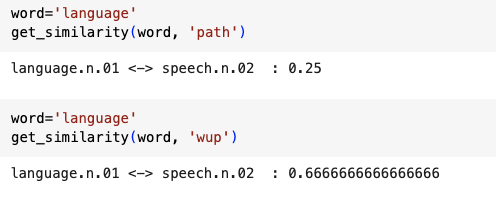

## E2. Calculate TF-IDF and search the Wiki page.

In this exercise, we will practise TF-IDF calculation using documents from [wikipedia library](https://pypi.org/project/wikipedia/), which is a Python library that makes it easy to access and parse data from Wikipedia. Based on the calculated TF-IDF, we then search the Wiki page for the word that has the top-1 TF-IDF value.

In [85]:
## Install and import the wikipedia library
!pip install wikipedia
import wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=4100652c939534d9b9d32060f1d73ab4e60ec8908450178526d3811ea6544f33
  Stored in directory: /root/.cache/pip/wheels/79/1d/c8/b64e19423cc5a2a339450ea5d145e7c8eb3d4aa2b150cde33b
Successfully built wikipedia


In [87]:
## Let's collect the page content from the following city related wiki pages as documents
## by using wikipedia.page(city).content, which returns a list of city related documents
cities_docs = ["Sydney","Melbourne","Brisbane"]
documents = [wikipedia.page(city).content for city in cities_docs]

## Let's see what documents (pages) we got
len(documents)

3

### Complete this section (Modify this section only)


Please fill in the following function(s) with code body:

Pass the (list of) documents provided above into the function as input. In the function, you may:
  
*   process the documents (e.g. tokenization) - provided in the sample code above. **Please add three additional stop words: sydney, melbourne and brisbane.**
*   calculate the TF-IDF values for each unique word ([Counter](https://docs.python.org/3/library/collections.html#collections.Counter) can be a one of the good choices).
*   sort the words based on the TF-IDF values and get the word with the highest TF-IDF value based on the sorting result. (Using Python built-in function [sorted](https://docs.python.org/3/howto/sorting.html) might be helpful for sorting)
*   search the wiki page for this word and print out the page content (Refer to how we search and retrieve the wiki page content for the city documents)


In [89]:
#sent_tokenize(documents[0])

In [105]:
## Import packages:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

import re
import numpy as np
from collections import Counter
import math

nltk.download('stopwords')
from nltk.corpus import stopwords as sw

cities_docs = ["Sydney", "Melbourne", "Brisbane"]
documents = [wikipedia.page(city).content for city in cities_docs]

## TF-IDF-oriented function:
def tfidf_wikisearch(documents):
    # Add the three additional stop words
    sww = sw.words() + ["sydney", "melbourne", "brisbane"]

    # process the documents: clean -> tokenize -> lowercase -> remove stopwords
    tokenized_documents = []
    for city_doc in documents:
        clean = re.sub(r'[^\w\s]', '', city_doc)
        tokens = word_tokenize(clean)
        tokens = [t.lower() for t in tokens]
        tokens = [w for w in tokens if w not in sww]
        tokenized_documents.append(tokens)

    # calculate Document Frequency (DF) first
    DF = {}
    for tokenized_doc in tokenized_documents:
        for term in np.unique(tokenized_doc):
            DF[term] = DF.get(term, 0) + 1

    # calculate the TF-IDF values for each unique word
    N = len(tokenized_documents)
    tf_idf = {}
    doc_id = 0
    for tokenized_doc in tokenized_documents:
        counter = Counter(tokenized_doc)
        total_num_words = len(tokenized_doc)
        for term in np.unique(tokenized_doc):
            tf = counter[term] / total_num_words
            df = DF[term]
            idf = math.log(N / (df + 1)) + 1
            tf_idf[doc_id, term] = tf * idf
        doc_id += 1

    # sort by TF-IDF value, descending, and get the top word
    sorted_tfidf = sorted(tf_idf.items(), key=lambda x: x[1], reverse=True)
    top_word = sorted_tfidf[0][0][1]


    # search the wiki page for this word and print out the page content
    page = wikipedia.page(top_word)


    print(f"Total document: {N}")
    print("Top TF-IDF word:", top_word)
    print(f"Page Content: \n",page.content)

# Call the function, the execution print out log should be kept for submission
tfidf_wikisearch(documents)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total document: 3
Top TF-IDF word: queensland
Page Content: 
 Queensland (locally  KWEENZ-land,  commonly abbreviated as QLD or Qld) is a state in northeastern Australia, the second-largest and third-most-populous state in Australia. It is bordered by the Northern Territory, South Australia and New South Wales to the west, south-west and south, respectively. To the east, Queensland is bounded by the Coral Sea and the Pacific Ocean; to the state's north is the Torres Strait, separating the Australian mainland from Papua New Guinea, and the Gulf of Carpentaria to the north-west. With an area of 1,723,030 square kilometres (665,270 sq mi), Queensland is the world's sixth-largest subdivision of any country on earth; it is larger than all but 16 countries. Due to its size, Queensland's geographical features and climates are diverse, and include tropical rainforests, rivers, coral reefs, mountain ranges and white sandy beaches in its tropical and sub-tropical coastal regions, as well as dese

###**E2 Sample output**

The following is **the sample output for E2** - **Your top1 TF-IDF word could be different from the following because of the wikipedia page changes.** Please just only check the output **format**, i.e. your output DO NOT need to be exactly the same.

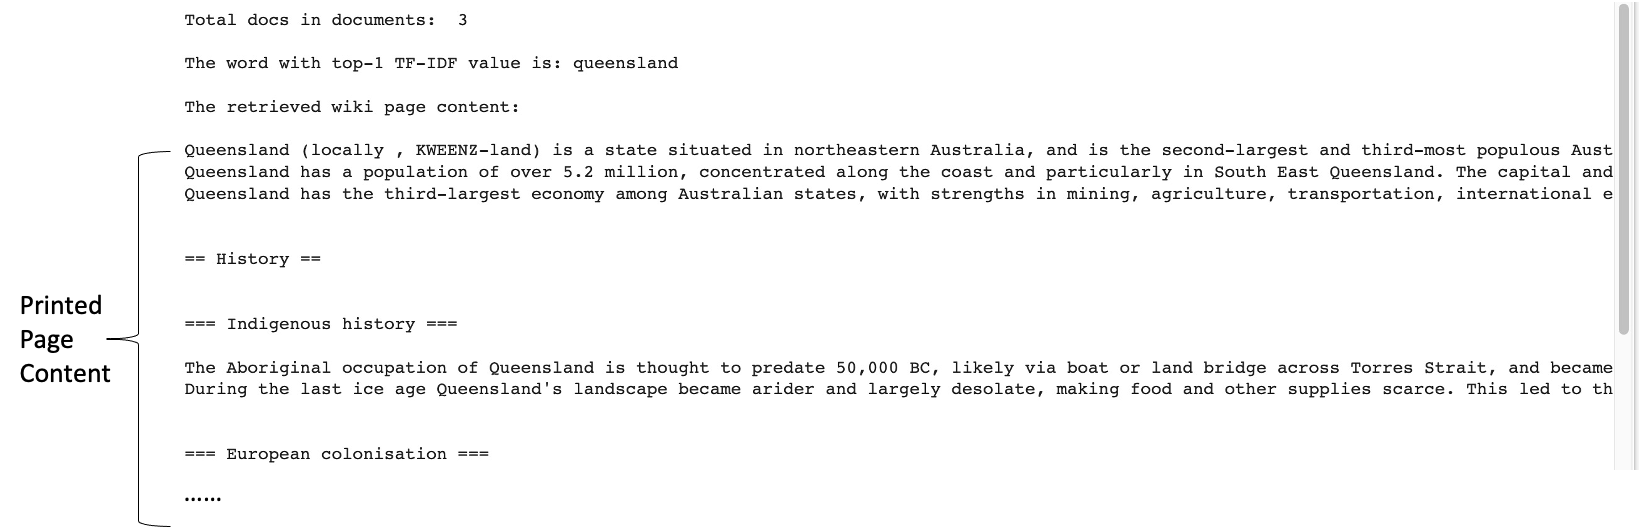